In [1]:
import os
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Path to dataset files:", path)

100%|██████████| 2.70G/2.70G [00:18<00:00, 158MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2


In [3]:
import os
import kagglehub
from pathlib import Path
from tqdm import tqdm

# Step 1: Download dataset using kagglehub
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
dataset_dir = Path(path)

# Step 2: Identify the nested "New Plant Diseases Dataset(Augmented)" folder
first_level_folder = dataset_dir / "New Plant Diseases Dataset(Augmented)"
second_level_folder = first_level_folder / "New Plant Diseases Dataset(Augmented)"  # The nested folder

# Step 3: Define correct paths
train_dir = second_level_folder / "train"
val_dir = second_level_folder / "valid"
test_dir = dataset_dir / "test" / "test"

# Step 4: Verify that paths exist
print(f"Train Directory Path: {train_dir}")
print(f"Validation Directory Path: {val_dir}")
print(f"Test Directory Path: {test_dir}")

print(f"Train directory exists: {train_dir.exists()}")
print(f"Validation directory exists: {val_dir.exists()}")
print(f"Test directory exists: {test_dir.exists()}")

# Step 5: Load Training Data Safely
if train_dir.exists():
    filenames_train = []
    label_train = []

    folds = os.listdir(train_dir)  # List all class folders
    for fold in tqdm(folds, desc="Processing Classes"):
        FoldPath = os.path.join(train_dir, fold)

        if os.path.isdir(FoldPath):  # Ensure it's a directory
            files = os.listdir(FoldPath)
            for file in files:
                filepath = os.path.join(FoldPath, file)
                filenames_train.append(filepath)
                label_train.append(fold)

    print(f"✅ Total Training Images: {len(filenames_train)}")
else:
    print("❌ No training data found. Check dataset structure.")

# Step 6: Load Validation Data Safely
if val_dir.exists():
    filenames_val = []
    label_val = []

    folds = os.listdir(val_dir)  # List all class folders
    for fold in tqdm(folds, desc="Processing Validation Classes"):
        FoldPath = os.path.join(val_dir, fold)

        if os.path.isdir(FoldPath):  # Ensure it's a directory
            files = os.listdir(FoldPath)
            for file in files:
                filepath = os.path.join(FoldPath, file)
                filenames_val.append(filepath)
                label_val.append(fold)

    print(f"✅ Total Validation Images: {len(filenames_val)}")
else:
    print("❌ No validation data found. Check dataset structure.")

# Step 7: Count Test Data
if test_dir.exists():
    total_test = len([f for f in test_dir.iterdir() if f.is_file()])
    print(f"✅ Total Test Images: {total_test}")
else:
    print("❌ No test data found.")


Train Directory Path: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Validation Directory Path: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Test Directory Path: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/test/test
Train directory exists: True
Validation directory exists: True
Test directory exists: True


Processing Classes: 100%|██████████| 38/38 [00:00<00:00, 345.25it/s]


✅ Total Training Images: 70295


Processing Validation Classes: 100%|██████████| 38/38 [00:00<00:00, 1136.00it/s]

✅ Total Validation Images: 17572
✅ Total Test Images: 33


In [4]:
path = Path(path)


# Now, path is a Path object and can be used for joining
actual_dataset_folder = path / "New Plant Diseases Dataset(Augmented)" / "New Plant Diseases Dataset(Augmented)"  # Adjusted for nested structure

train_dir = actual_dataset_folder / "train"
val_dir = actual_dataset_folder / "valid"
test_dir = path / "test" / "test"  # Adjusted to use path directly

# Print paths
print(f"Train Directory : {train_dir}")
print(f"Validation Directory : {val_dir}")
print(f"Test Directory : {test_dir}")


Train Directory : /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Validation Directory : /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Test Directory : /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2/test/test


In [5]:
total_class_train = len(os.listdir(train_dir))
total_class_val = len(os.listdir(val_dir))
total_test = len(os.listdir(test_dir))

print(f"Total of Train Data Classes: {total_class_train} classes")
print(f"Total of Validation Data Classes: {total_class_val} classes")
print(f"Total of Test Data: {total_test} images")

Total of Train Data Classes: 38 classes
Total of Validation Data Classes: 38 classes
Total of Test Data: 33 images


In [6]:
def count_data_per_class(path):
    classes = sorted(os.listdir(path))
    class_counts = {}
    for cls in classes:
        class_path = os.path.join(path, cls)
        class_counts[cls] = len(os.listdir(class_path))
    return class_counts

train_class_counts = count_data_per_class(train_dir)
val_class_counts = count_data_per_class(val_dir)

train_counts_df = pd.DataFrame.from_dict(train_class_counts, orient="index", columns=["Count"])
val_counts_df = pd.DataFrame.from_dict(val_class_counts, orient="index", columns=["Count"])

print(f"Total Image for Training: {sum(train_class_counts.values())} images")
print(f"Total Image for Validation: {sum(val_class_counts.values())} images")

Total Image for Training: 70295 images
Total Image for Validation: 17572 images


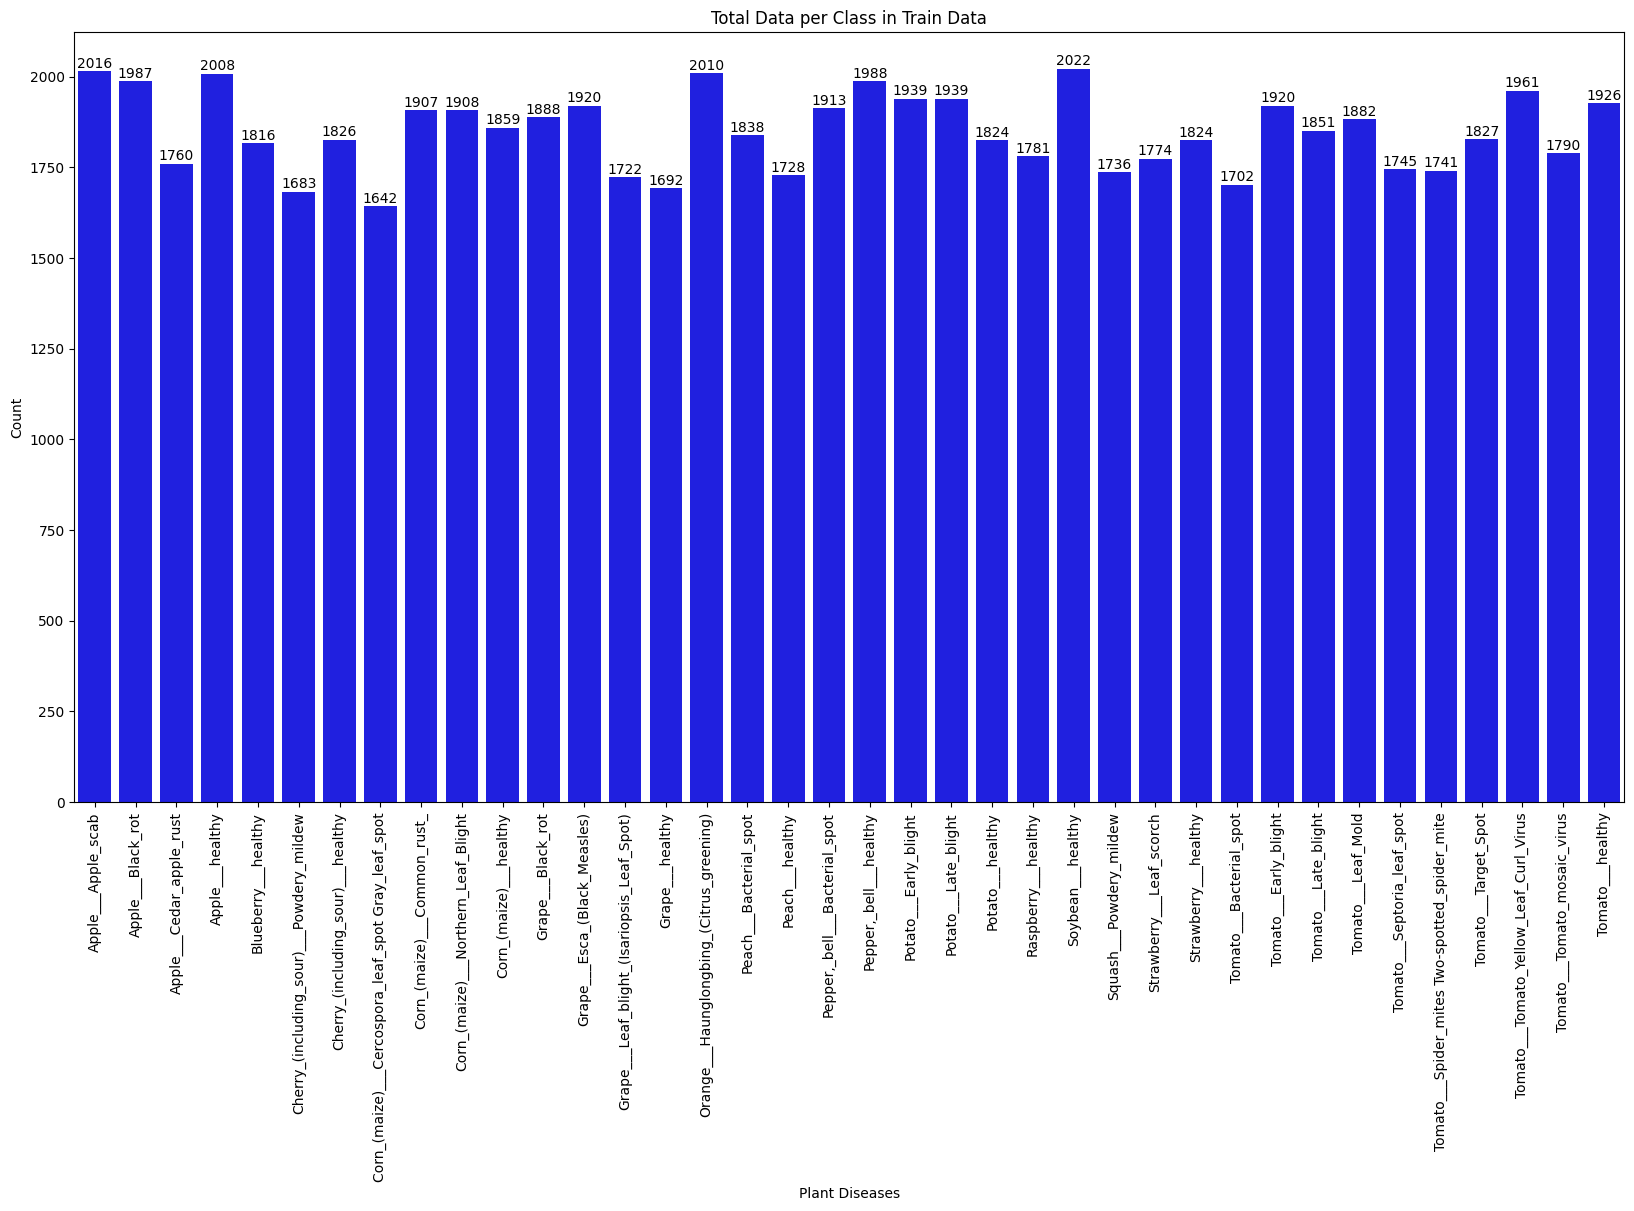

In [7]:
# Plot total data per class for training data
plt.figure(figsize=(20, 10))
sns.barplot(data=train_counts_df, x=train_counts_df.index, y="Count", color="blue")
plt.title("Total Data per Class in Train Data")
plt.xlabel("Plant Diseases")
plt.ylabel("Count")
plt.xticks(rotation=90)
ax = plt.gca()
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 10,
            '{:1.0f}'.format(p.get_height()), ha="center")
plt.savefig("Total Data per Class in Train Data.jpg")
plt.show()

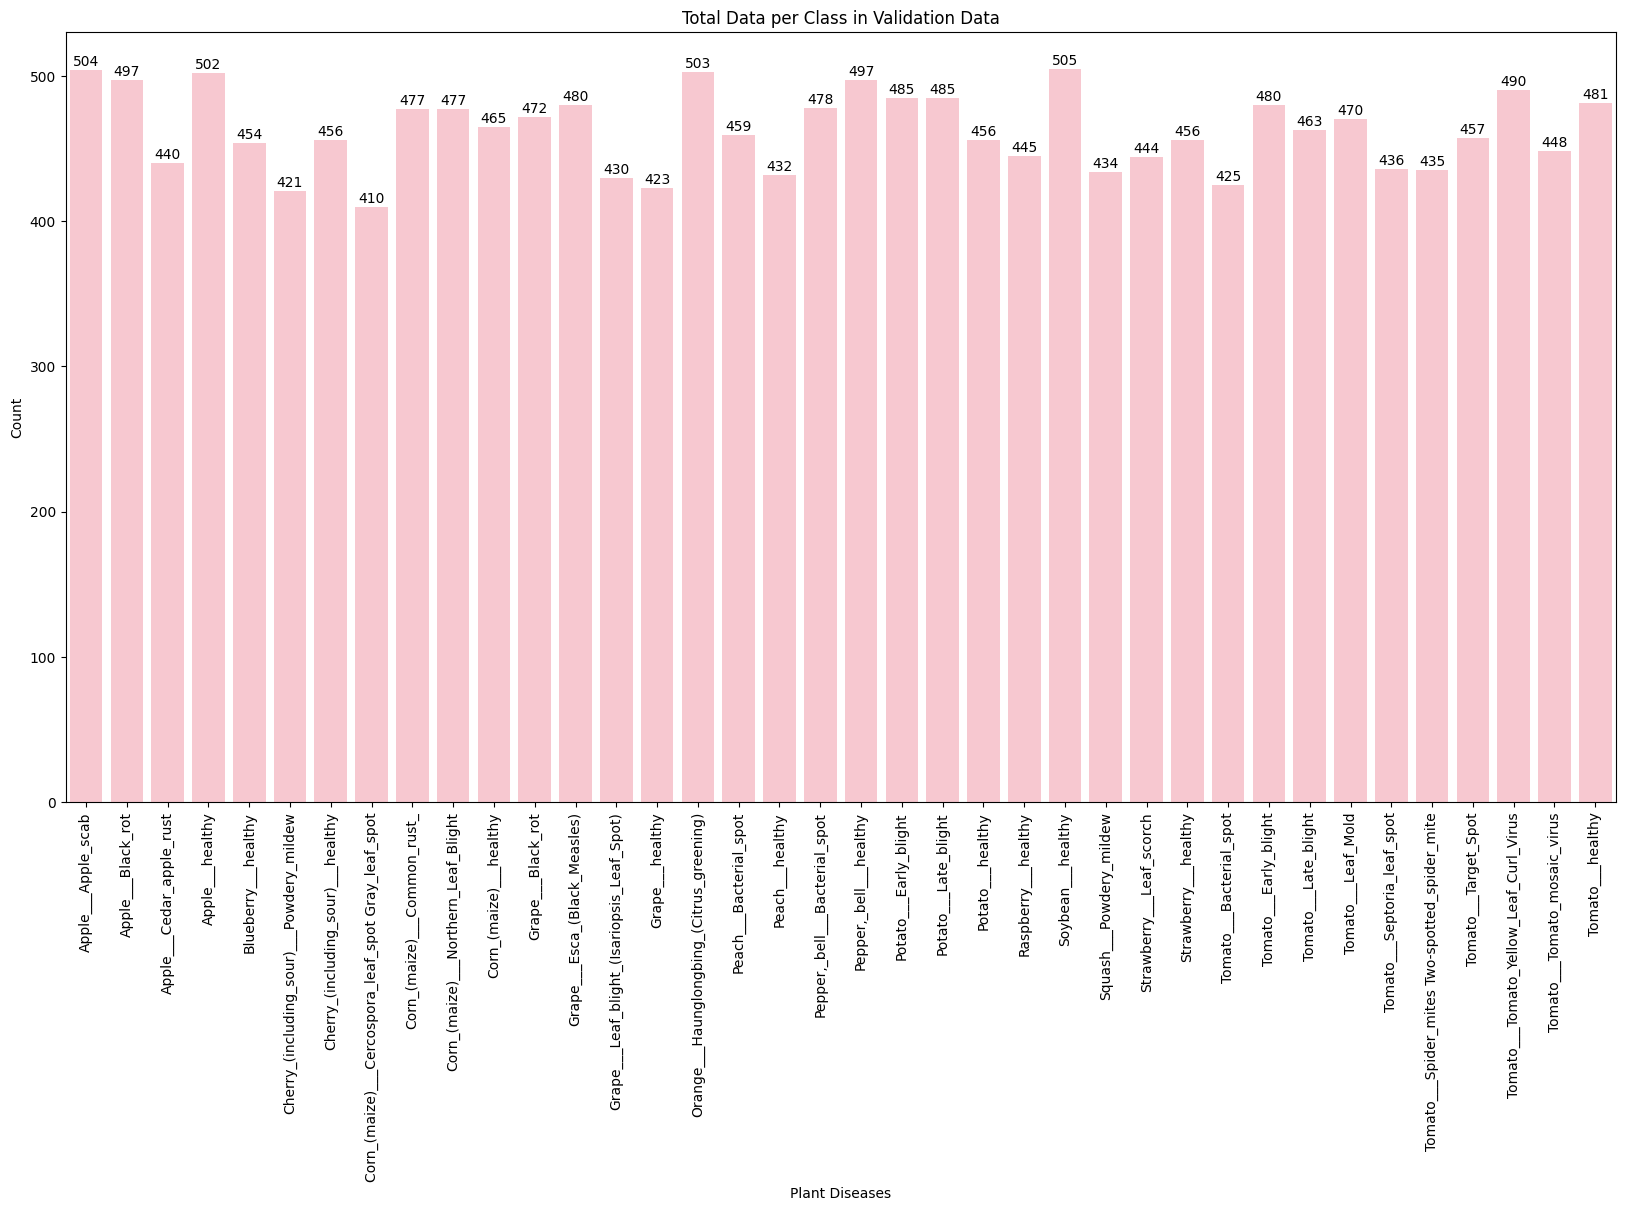

In [8]:
# Plot total data per class for validation data
plt.figure(figsize=(20, 10))
sns.barplot(data=val_counts_df, x=val_counts_df.index, y="Count", color="pink")
plt.title("Total Data per Class in Validation Data")
plt.xlabel("Plant Diseases")
plt.ylabel("Count")
plt.xticks(rotation=90)
ax = plt.gca()
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 3,
            '{:1.0f}'.format(p.get_height()), ha="center")
plt.savefig("Total Data per Class in Validation Data.jpg")
plt.show()

In [9]:
all_diseases = sorted(os.listdir(train_dir))
plants = []
for cls in all_diseases:
    plant = cls.split("___")[0]
    if plant not in plants:
        plants.append(plant)

num_plants = len(plants)
print(f"Number of Plants: {num_plants} plants")
print("Kind of Plants: ")
for i, plant in enumerate(plants):
    print(f"{i+1}. {plant}")

Number of Plants: 14 plants
Kind of Plants: 
1. Apple
2. Blueberry
3. Cherry_(including_sour)
4. Corn_(maize)
5. Grape
6. Orange
7. Peach
8. Pepper,_bell
9. Potato
10. Raspberry
11. Soybean
12. Squash
13. Strawberry
14. Tomato


In [10]:
diseases = []
for cls in all_diseases:
    disease = cls.split("___")[1]
    if disease not in diseases:
        if disease != "healthy":
            diseases.append(disease)
num_diseases = len(diseases)
print(f"\nNumber of Diseases: {num_diseases} diseases")
print("Kind of Diseases: ")
for i, disease in enumerate(diseases):
    print(f"{i+1}. {disease}")


Number of Diseases: 20 diseases
Kind of Diseases: 
1. Apple_scab
2. Black_rot
3. Cedar_apple_rust
4. Powdery_mildew
5. Cercospora_leaf_spot Gray_leaf_spot
6. Common_rust_
7. Northern_Leaf_Blight
8. Esca_(Black_Measles)
9. Leaf_blight_(Isariopsis_Leaf_Spot)
10. Haunglongbing_(Citrus_greening)
11. Bacterial_spot
12. Early_blight
13. Late_blight
14. Leaf_scorch
15. Leaf_Mold
16. Septoria_leaf_spot
17. Spider_mites Two-spotted_spider_mite
18. Target_Spot
19. Tomato_Yellow_Leaf_Curl_Virus
20. Tomato_mosaic_virus


In [11]:
# Display 10 random images with labels and shapes
image_path_list = list(dataset_dir.glob("*/*/*.jpg"))
random_image_paths = random.sample(image_path_list, 10)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 20))
for i, ax in enumerate(axes.flat):
    random_image_path = random_image_paths[i]  # Get image path
    image_class = random_image_path.parent.stem  # Get image class from directory name
    image = Image.open(random_image_path)  # Open image
    ax.imshow(image)  # Display image on subplot
    # Add label and shape of the image
    ax.set_title(f"Label: {image_class}\nShape: {image.height}x{image.width}x{3 if image.mode=='RGB' else 1}")
    ax.axis("off")
plt.tight_layout()
plt.show()


ValueError: Sample larger than population or is negative

In [11]:
# ---------------------------
# Data Transformations & Dataset Creation using TensorFlow
# ---------------------------
# Define parameters
BatchSize = 32
width, height = 224, 224

# Option for using only a subset of data (e.g. 10% of the total)
data_percentage = 0.1  # Change to 0.2 for 20%, 1.0 for 100% etc.

# Create full training and validation datasets using image_dataset_from_directory
train_dataset_full = tf.keras.preprocessing.image_dataset_from_directory(
    directory=str(train_dir),
    labels="inferred",
    label_mode="categorical",
    batch_size=BatchSize,
    image_size=(width, height),
    shuffle=True,
    seed=123
)

val_dataset_full = tf.keras.preprocessing.image_dataset_from_directory(
    directory=str(val_dir),
    labels="inferred",
    label_mode="categorical",
    batch_size=BatchSize,
    image_size=(width, height),
    shuffle=True,
    seed=123
)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [12]:
# Determine the number of batches in each full dataset
num_train_batches = tf.data.experimental.cardinality(train_dataset_full).numpy()
num_val_batches = tf.data.experimental.cardinality(val_dataset_full).numpy()

# Calculate the new number of batches to use based on data_percentage
train_steps = int(num_train_batches * data_percentage)
val_steps = int(num_val_batches * data_percentage)

# Use .take() to create the subset datasets
train_dataset = train_dataset_full.take(train_steps)
val_dataset = val_dataset_full.take(val_steps)

print(f"Using {train_steps * BatchSize} training images and {val_steps * BatchSize} validation images.")

Using 7008 training images and 1760 validation images.


In [13]:
import tensorflow as tf
import os
from pathlib import Path

# Get class names from the full training dataset
class_names = train_dataset_full.class_names  # e.g., ['Apple___Apple_scab', 'Apple___Black_rot', ...]
num_classes = len(class_names)

# Create a lookup table mapping class names to integer indices
lookup_table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(class_names),
        values=tf.constant(list(range(num_classes)), dtype=tf.int64)
    ),
    default_value=-1
)

def process_image(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [width, height])
    img = img / 255.0
    return img

def get_label(file_path):
    # Split the path by os.sep and get the second-to-last part as the label
    parts = tf.strings.split(file_path, os.sep)
    label_str = parts[-2]
    # Lookup the integer label using the lookup table
    label_index = lookup_table.lookup(label_str)
    # One-hot encode the label
    return tf.one_hot(label_index, depth=num_classes)

# List test files (assuming test images are directly under test_dir)
test_files = tf.data.Dataset.list_files(str(test_dir / '*.[Jj][Pp][Gg]'), shuffle=False)

# Map processing functions to get (image, label) tuples, then batch the dataset
test_dataset = test_files.map(lambda x: (process_image(x), get_label(x)))
test_dataset = test_dataset.batch(BatchSize)

In [14]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")
import tensorflow as tf
import numpy as np
import tensorflow
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPool2D, MaxPooling2D, AveragePooling2D, Dense, Flatten, BatchNormalization, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Lambda
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

## ResNet50

In [15]:
base_model_tf = ResNet50(include_top=False, weights='imagenet', input_shape=(224,224,3), classes=38)
base_model_tf.trainable = False

pt = Input(shape=(224,224,3))
func = Lambda(lambda x: tensorflow.cast(x, tensorflow.float32))(pt)
x = preprocess_input(func)
model_resnet = base_model_tf(x, training=False)
model_resnet = GlobalAveragePooling2D()(model_resnet)
model_resnet = Dense(128, activation='relu')(model_resnet)
model_resnet = Dense(64, activation='relu')(model_resnet)
model_resnet = Dense(38, activation='softmax')(model_resnet)
model_main = Model(inputs=pt, outputs=model_resnet)
model_main.summary()

# Image augmentation
train_datagen = ImageDataGenerator(shear_range = 0.2, zoom_range = 0.2, horizontal_flip = False,
                                   vertical_flip = False, fill_mode = 'nearest', width_shift_range = 0.2,
                                   height_shift_range = 0.2)
val_datagen=ImageDataGenerator()

# Train and validation data
path_train= train_dir
path_valid= val_dir

# From directory
train = train_datagen.flow_from_directory(directory=path_train, batch_size=32, target_size=(224,224),
                                         color_mode='rgb', class_mode='categorical', seed=0)
valid = val_datagen.flow_from_directory(directory=path_valid, batch_size=32, target_size=(224,224),
                                      color_mode='rgb', class_mode='categorical')

# CallBacks
es = EarlyStopping(monitor='val_accuracy', verbose=True, patience=7, mode='auto')
mc = ModelCheckpoint(filepath='/content/best_model.keras', monitor='val_accuracy', verbose=True, save_best_only=True)
lr = ReduceLROnPlateau(monitor='val_accuracy', verbose=True, patience=5, min_lr=0.001)

# Compile
model_main.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training and capturing history
history_resnet = model_main.fit(train, validation_data=valid, epochs=20, steps_per_epoch=300, verbose=True, callbacks=[mc, es, lr])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 224, 224, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item (GetItem)        │ (None, 224, 224)       │              0 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_1 (GetItem)      │ (None, 224, 224)       │              0 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_2 (GetItem)      │ (None, 224, 224)       │              0 │ lambda[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stack (Stack)             │ (None, 224, 224, 3)    │              0 │ get_item[0][0],        │
│                           │                        │                │ get_item_1[0][0],      │
│                           │                        │                │ get_item_2[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 224, 224, 3)    │              0 │ stack[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ resnet50 (Functional)     │ (None, 7, 7, 2048)     │     23,587,712 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 2048)           │              0 │ resnet50[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │        262,272 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │          8,256 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 38)             │          2,470 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 23,860,710 (91.02 MB)

 Trainable params: 272,998 (1.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.4827 - loss: 1.9967
Epoch 1: val_accuracy improved from -inf to 0.86763, saving model to /content/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 187s 576ms/step - accuracy: 0.4834 - loss: 1.9938 - val_accuracy: 0.8676 - val_loss: 0.4241 - learning_rate: 0.0010
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8756 - loss: 0.3955
Epoch 2: val_accuracy improved from 0.86763 to 0.89717, saving model to /content/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 166s 556ms/step - accuracy: 0.8756 - loss: 0.3954 - val_accuracy: 0.8972 - val_loss: 0.3229 - learning_rate: 0.0010
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9184 - loss: 0.2661
Epoch 3: val_accuracy improved from 0.89717 to 0.91987, saving model to /content/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 165s 551ms/step - accuracy: 0.9184 - l

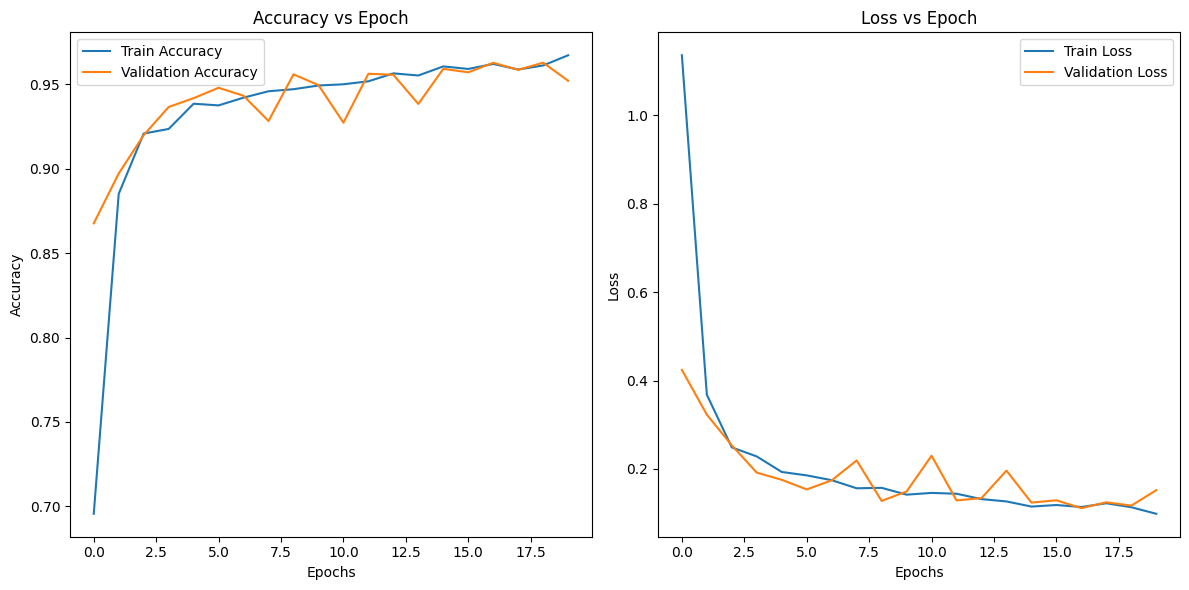

In [16]:


# Accessing the history of accuracy and loss from the history_resnet variable
train_loss = history_resnet.history['loss']
val_loss = history_resnet.history['val_loss']
train_accuracy = history_resnet.history['accuracy']
val_accuracy = history_resnet.history['val_accuracy']

# Plotting accuracy vs. loss
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()


## CNN

In [17]:
train_gen = image_dataset_from_directory(directory=train_dir,
                                         image_size=(256, 256))

test_gen = image_dataset_from_directory(directory=val_dir,
                                        image_size=(256, 256))

rescale = Rescaling(scale=1.0/255)
train_gen = train_gen.map(lambda image,label:(rescale(image),label))
test_gen = test_gen.map(lambda image,label:(rescale(image),label))

model = keras.Sequential()

model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same",input_shape=(256,256,3)))
model.add(keras.layers.Conv2D(32,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(64,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(128,(3,3),activation="relu",padding="same"))
model.add(keras.layers.MaxPooling2D(3,3))

model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(256,(3,3),activation="relu",padding="same"))

model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))
model.add(keras.layers.Conv2D(512,(5,5),activation="relu",padding="same"))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(1568,activation="relu"))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(38,activation="softmax"))

opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt,loss="sparse_categorical_crossentropy",metrics=['accuracy'])
model.summary()

# Training and capturing history

history_cnn = model.fit(train_gen, validation_data=test_gen, epochs=20, steps_per_epoch=300)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 256, 256, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 85, 85, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 85, 85, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 85, 85, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 9, 9, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 9, 9, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 9, 9, 512)           │       3,277,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 9, 9, 512)           │       6,554,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 41472)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1568)                │      65,029,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1568)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 38)                  │          59,622 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 76,092,966 (290.27 MB)

 Trainable params: 76,092,966 (290.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 100s 272ms/step - accuracy: 0.0391 - loss: 3.5669 - val_accuracy: 0.1395 - val_loss: 3.0586
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 61s 205ms/step - accuracy: 0.2054 - loss: 2.8172 - val_accuracy: 0.4561 - val_loss: 1.7937
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 61s 205ms/step - accuracy: 0.4776 - loss: 1.7379 - val_accuracy: 0.6367 - val_loss: 1.1901
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 62s 208ms/step - accuracy: 0.6021 - loss: 1.3014 - val_accuracy: 0.7198 - val_loss: 0.9073
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 63s 209ms/step - accuracy: 0.6782 - loss: 1.0545 - val_accuracy: 0.7448 - val_loss: 0.8128
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 62s 208ms/step - accuracy: 0.7236 - loss: 0.8806 - val_accuracy: 0.7668 - val_loss: 0.7355
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 64s 213ms/step - accuracy: 0.7573 - loss: 0.7803 - val_accuracy: 0.8016 - val_loss: 0.6133
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 52s 173ms/step - accuracy: 0.7603 - loss: 

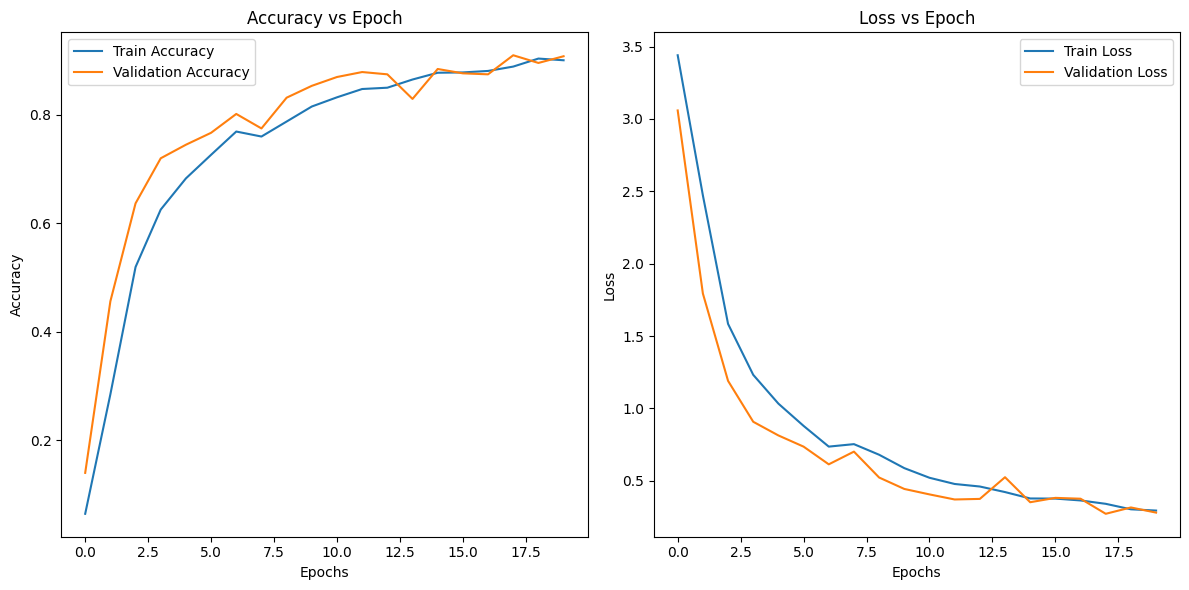

In [18]:

# Accessing the history of accuracy and loss from the history_cnn variable
train_loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']
train_accuracy = history_cnn.history['accuracy']
val_accuracy = history_cnn.history['val_accuracy']

# Plotting accuracy vs. loss
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

## Inception

In [19]:
# InceptionV3
base_model_tf = InceptionV3(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model_tf.trainable = False

pt = Input(shape=(224,224,3))
func = Lambda(lambda x: tensorflow.cast(x, tensorflow.float32))(pt)
x = preprocess_input(func)
model_inception = base_model_tf(x, training=False)
model_inception = GlobalAveragePooling2D()(model_inception)
model_inception = Dense(128, activation='relu')(model_inception)
model_inception = Dense(64, activation='relu')(model_inception)
model_inception = Dense(38, activation='softmax')(model_inception)
model_main = Model(inputs=pt, outputs=model_inception)
model_main.summary()

# Image augmentation
train_datagen = ImageDataGenerator(shear_range = 0.2, zoom_range = 0.2, horizontal_flip = False,
                                   vertical_flip = False, fill_mode = 'nearest', width_shift_range = 0.2,
                                   height_shift_range = 0.2)
val_datagen = ImageDataGenerator()

# Train and validation data
path_train= train_dir
path_valid= val_dir

# From directory
train = train_datagen.flow_from_directory(directory=path_train, batch_size=32, target_size=(224,224),
                                         color_mode='rgb', class_mode='categorical', seed=0)
valid = val_datagen.flow_from_directory(directory=path_valid, batch_size=32, target_size=(224,224),
                                      color_mode='rgb', class_mode='categorical')

# CallBacks
es = EarlyStopping(monitor='val_accuracy', verbose=True, patience=7, mode='auto')
mc = ModelCheckpoint(filepath='/content/best_model.keras', monitor='val_accuracy', verbose=True, save_best_only=True)
lr = ReduceLROnPlateau(monitor='val_accuracy', verbose=True, patience=5, min_lr=0.001)

# Compile
model_main.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training and capturing history
history_inception = model_main.fit(train, validation_data=valid, epochs=20, steps_per_epoch=300, verbose=True, callbacks=[mc, es, lr])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_1 (Lambda)         │ (None, 224, 224, 3)    │              0 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_3 (GetItem)      │ (None, 224, 224)       │              0 │ lambda_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_4 (GetItem)      │ (None, 224, 224)       │              0 │ lambda_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_5 (GetItem)      │ (None, 224, 224)       │              0 │ lambda_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stack_1 (Stack)           │ (None, 224, 224, 3)    │              0 │ get_item_3[0][0],      │
│                           │                        │                │ get_item_4[0][0],      │
│                           │                        │                │ get_item_5[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 224, 224, 3)    │              0 │ stack_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ inception_v3 (Functional) │ (None, 5, 5, 2048)     │     21,802,784 │ add_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 2048)           │              0 │ inception_v3[0][0]     │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 128)            │        262,272 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 64)             │          8,256 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 38)             │          2,470 │ dense_6[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 22,075,782 (84.21 MB)

 Trainable params: 272,998 (1.04 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.0332 - loss: 4.9412
Epoch 1: val_accuracy improved from -inf to 0.04587, saving model to /content/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 192s 577ms/step - accuracy: 0.0332 - loss: 4.9377 - val_accuracy: 0.0459 - val_loss: 3.5657 - learning_rate: 0.0010
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.0488 - loss: 3.5669
Epoch 2: val_accuracy improved from 0.04587 to 0.06192, saving model to /content/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 161s 539ms/step - accuracy: 0.0488 - loss: 3.5669 - val_accuracy: 0.0619 - val_loss: 3.5418 - learning_rate: 0.0010
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.0618 - loss: 3.5251
Epoch 3: val_accuracy improved from 0.06192 to 0.07170, saving model to /content/best_model.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 153s 510ms/step - accuracy: 0.0618 - l

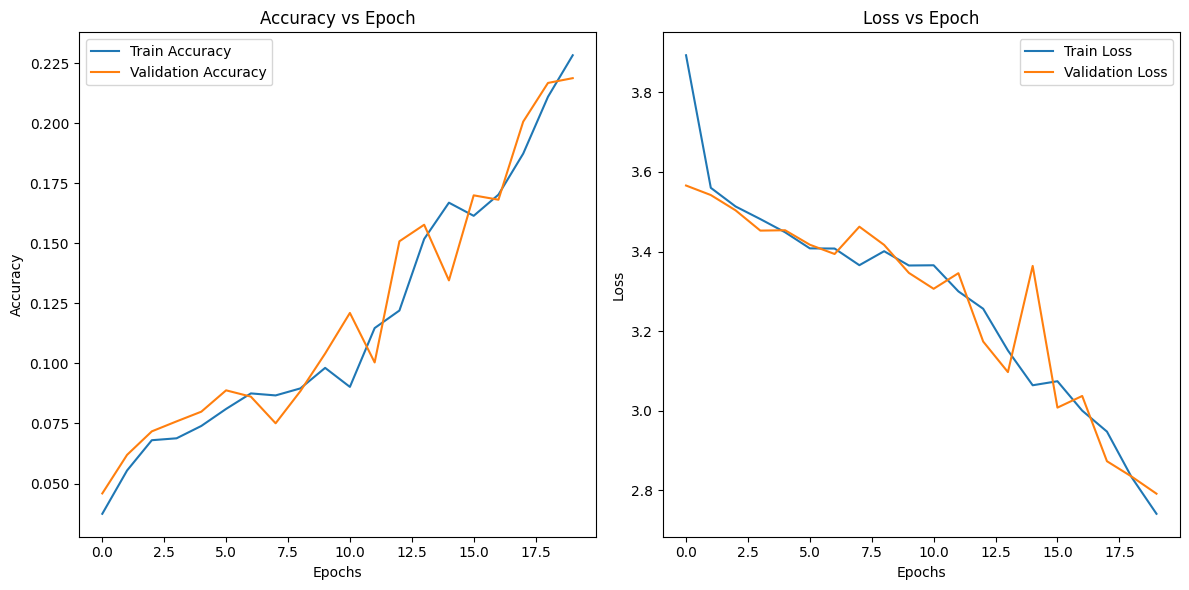

In [20]:
# Accessing the history of accuracy and loss from the history_inception variable
train_loss = history_inception.history['loss']
val_loss = history_inception.history['val_loss']
train_accuracy = history_inception.history['accuracy']
val_accuracy = history_inception.history['val_accuracy']

# Plotting accuracy vs. loss
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

## VGG_16

In [21]:
base_model_tf = VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model_tf.trainable = False

pt = Input(shape=(224,224,3))
func = Lambda(lambda x: tensorflow.cast(x, tensorflow.float32))(pt)
x = preprocess_input(func)
model_vgg = base_model_tf(x, training=False)
model_vgg = GlobalAveragePooling2D()(model_vgg)
model_vgg = Dense(128, activation='relu')(model_vgg)
model_vgg = Dense(64, activation='relu')(model_vgg)
model_vgg = Dense(38, activation='softmax')(model_vgg)
model_main = Model(inputs=pt, outputs=model_vgg)
model_main.summary()

# Image augmentation
train_datagen = ImageDataGenerator(shear_range = 0.2, zoom_range = 0.2, horizontal_flip = False,
                                   vertical_flip = False, fill_mode = 'nearest', width_shift_range = 0.2,
                                   height_shift_range = 0.2)
val_datagen=ImageDataGenerator()

# Train and validation data
path_train= train_dir
path_valid= val_dir

# From directory
train = train_datagen.flow_from_directory(directory=path_train, batch_size=32, target_size=(224,224),
                                         color_mode='rgb', class_mode='categorical', seed=0)
valid = val_datagen.flow_from_directory(directory=path_valid, batch_size=32, target_size=(224,224),
                                      color_mode='rgb', class_mode='categorical')

# CallBacks
es = EarlyStopping(monitor='val_accuracy', verbose=True, patience=7, mode='auto')
mc = ModelCheckpoint(filepath='/content/best_model.keras', monitor='val_accuracy', verbose=True, save_best_only=True)
lr = ReduceLROnPlateau(monitor='val_accuracy', verbose=True, patience=5, min_lr=0.001)

# Compile
model_main.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Training and capturing history
history_vgg = model_main.fit(train, validation_data=valid, epochs=10, steps_per_epoch=200, verbose=True, callbacks=[mc, es, lr])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_2 (Lambda)         │ (None, 224, 224, 3)    │              0 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_6 (GetItem)      │ (None, 224, 224)       │              0 │ lambda_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_7 (GetItem)      │ (None, 224, 224)       │              0 │ lambda_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ get_item_8 (GetItem)      │ (None, 224, 224)       │              0 │ lambda_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stack_2 (Stack)           │ (None, 224, 224, 3)    │              0 │ get_item_6[0][0],      │
│                           │                        │                │ get_item_7[0][0],      │
│                           │                        │                │ get_item_8[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 224, 224, 3)    │              0 │ stack_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 7, 7, 512)      │     14,714,688 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 512)            │              0 │ vgg16[0][0]            │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 128)            │         65,664 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 64)             │          8,256 │ dense_8[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 38)             │          2,470 │ dense_9[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 14,791,078 (56.42 MB)

 Trainable params: 76,390 (298.40 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.2727 - loss: 2.8871
Epoch 1: val_accuracy improved from -inf to 0.67425, saving model to /content/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 201s 932ms/step - accuracy: 0.2736 - loss: 2.8826 - val_accuracy: 0.6743 - val_loss: 1.0665 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.7490 - loss: 0.8284
Epoch 2: val_accuracy improved from 0.67425 to 0.80697, saving model to /content/best_model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 182s 914ms/step - accuracy: 0.7492 - loss: 0.8279 - val_accuracy: 0.8070 - val_loss: 0.6153 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.8154 - loss: 0.5904
Epoch 3: val_accuracy did not improve from 0.80697
200/200 ━━━━━━━━━━━━━━━━━━━━ 182s 913ms/step - accuracy: 0.8154 - loss: 0.5902 - val_accuracy: 0.7988 - val_loss: 

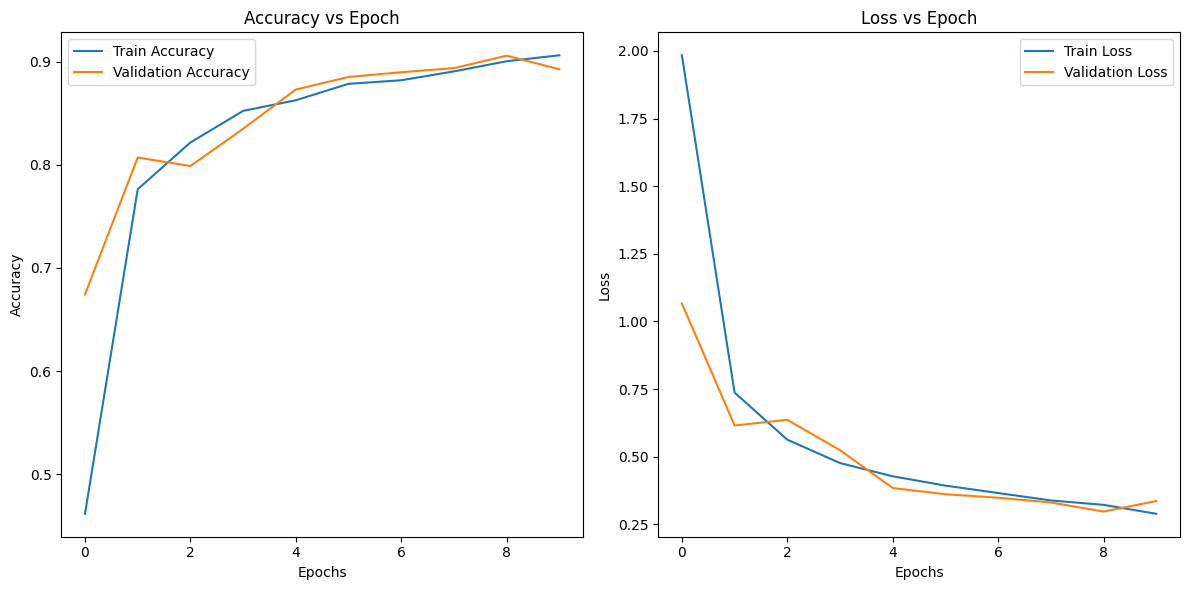

In [22]:
# Accessing the history of accuracy and loss from the history_vgg variable
train_loss = history_vgg.history['loss']
val_loss = history_vgg.history['val_loss']
train_accuracy = history_vgg.history['accuracy']
val_accuracy = history_vgg.history['val_accuracy']

# Plotting accuracy vs. loss
plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Display the plots
plt.tight_layout()
plt.show()

The accuracy for ResNet-50: 96.7
The accuracy for CNN: 91.4
The accuracy for VGG: 92.2
The accuracy for Inception: 26.7


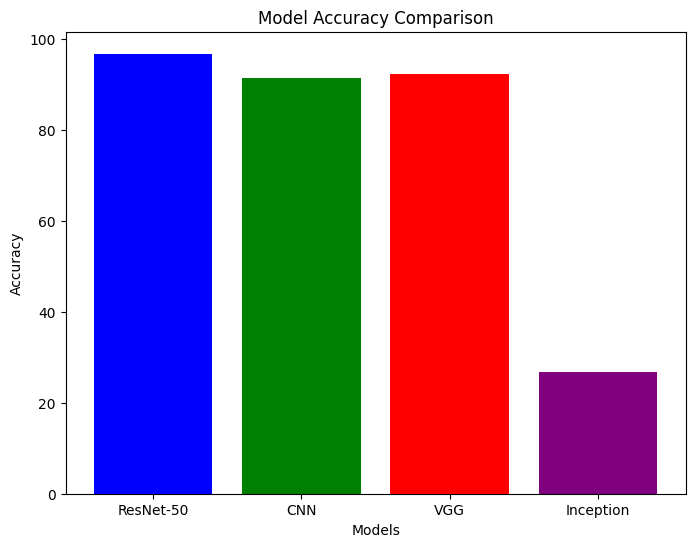

In [2]:
# Model Comparison

import matplotlib.pyplot as plt

# Input the accuracy for each model
resnet50_accuracy = float(input("The accuracy for ResNet-50: "))
cnn_accuracy = float(input("The accuracy for CNN: "))
vgg_accuracy = float(input("The accuracy for VGG: "))
inception_accuracy = float(input("The accuracy for Inception: "))

# Model names
models = ['ResNet-50', 'CNN', 'VGG', 'Inception']

# Accuracy values
accuracies = [resnet50_accuracy, cnn_accuracy, vgg_accuracy, inception_accuracy]

# Create the bar plot
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'green', 'red', 'purple'])

# Add labels and title
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')

# Show the plot
plt.show()


## FL

In [23]:
# Multiple clients
num_clients = 3
client_train_data = []
client_test_data = []

train_gen = image_dataset_from_directory(directory=train_dir, image_size=(256, 256))
test_gen = image_dataset_from_directory(directory=val_dir, image_size=(256, 256))

# Calculate how many steps per client
steps_per_epoch = len(train_gen)

# Split data for clients
client_data_size = steps_per_epoch // num_clients
for i in range(num_clients):
    # Dataset for the client
    train_client_data = train_gen.skip(i * client_data_size).take(client_data_size)
    test_client_data = test_gen.skip(i * client_data_size).take(client_data_size)

    client_train_data.append(train_client_data)
    client_test_data.append(test_client_data)

# Model
def create_model():
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(256, 256, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(3, 3))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(3, 3))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(3, 3))

    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))

    model.add(Conv2D(512, (5, 5), activation='relu', padding='same'))
    model.add(Conv2D(512, (5, 5), activation='relu', padding='same'))

    model.add(Flatten())
    model.add(Dense(1568, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(38, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Client-side training
client_models = []
client_histories = []

# Create and train a model for each client
for i in range(num_clients):
    model = create_model()
    model.fit(client_train_data[i], epochs=20, steps_per_epoch=300)
    client_models.append(model)
    client_histories.append(model.history)

# Aggregate weights
def aggregate_weights(models):
    # Aggregated weights
    aggregated_weights = []

    for layer in models[0].layers:
        # Weights for this layer
        layer_weights = layer.get_weights()
        aggregated_weights.append([np.zeros_like(w) for w in layer_weights])

    # Sum weights from all models
    for model in models:
        for i, layer in enumerate(model.layers):
            weights = layer.get_weights()
            for j in range(len(weights)):
                aggregated_weights[i][j] += weights[j]

    # Average the weights
    num_models = len(models)
    for i in range(len(aggregated_weights)):
        for j in range(len(aggregated_weights[i])):
            aggregated_weights[i][j] = aggregated_weights[i][j] / num_models

    try:
        models[0].set_weights(aggregated_weights)
    except:
        pass

# Aggregate the weights:
aggregate_weights(client_models)

# Evaluate the aggregated model
global_model = client_models[0]
global_model.evaluate(test_gen, steps=100)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 50s 144ms/step - accuracy: 0.1165 - loss: 3.4012
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 142ms/step - accuracy: 0.4942 - loss: 1.7166
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.6558 - loss: 1.1252 
Epoch 4/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 78s 145ms/step - accuracy: 0.6978 - loss: 0.9806
Epoch 5/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 142ms/step - accuracy: 0.7540 - loss: 0.8079
Epoch 6/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.7941 - loss: 0.6591 
Epoch 7/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 143ms/step - accuracy: 0.8328 - loss: 0.5527
Epoch 8/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 43s 142ms/step - accuracy: 0.8596 - loss: 0.4463
Epoch 9/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.8886 - loss: 0.3721 
Epoch 10/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - accuracy: 0.8886 - loss: 0.3523
Epoch 11/20
300/300 ━━━

[0.45937907695770264, 0.8831250071525574]